In [55]:
import tempfile
import pickle
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from one.api import ONE
from scipy.special import logit, softmax
import os
from os.path import join
import pickle as pkl
from brainwidemap.bwm_loading import bwm_query, bwm_units, load_trials_and_mask, merge_probes

import concurrent.futures
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import sys

from one.api import ONE
from brainbox.io.one import SessionLoader
from iblatlas.atlas import BrainRegions
from sklearn.metrics import balanced_accuracy_score

from brainwidemap.bwm_loading import (
    bwm_query,
    load_good_units,
    load_trials_and_mask,
    merge_probes,
    bwm_units,
)
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

In [3]:
df = bwm_query()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [104]:
df['eid'].unique()[0]

'6713a4a7-faed-4df2-acab-ee4e63326f8d'

In [4]:
eid = df['eid'][0]

In [106]:
eids = df['eid'].unique()

In [120]:
qc = {}
for eid in eids:
    qc[eid] = [np.nan, True]

In [121]:
a = pd.DataFrame.from_dict(qc, orient='index', columns=['contrast','feedback'])

In [ ]:
a.to_parquet

,contrast,feedback
6713a4a7-faed-4df2-acab-ee4e63326f8d,NaN,True
56956777-dca5-468c-87cb-78150432cc57,NaN,True
4364a246-f8d7-4ce7-ba23-a098104b96e4,NaN,True
b182b754-3c3e-4942-8144-6ee790926b58,NaN,True
a8a8af78-16de-4841-ab07-fde4b5281a03,NaN,True
...,...,...
fcd49e34-f07b-441c-b2ac-cb8c462ec5ac,NaN,True
5522ac4b-0e41-4c53-836a-aaa17e82b9eb,NaN,True
993c7024-0abc-4028-ad30-d397ad55b084,NaN,True
fece187f-b47f-4870-a1d6-619afe942a7d,NaN,True


In [10]:
one = ONE()
one.load_cache(clobber=True)

Downloading: /Users/dkundu/Downloads/ONE/openalyx.internationalbrainlab.org/tmpret_juxk/cache.zip Bytes: 14854680


100%|██████████| 14.166526794433594/14.166526794433594 [00:00<00:00, 15.49it/s]


datetime.datetime(2026, 7, 7, 11, 52, 51, 830957)

In [11]:
sess = SessionLoader(one, eid)

In [12]:
sess.load_pupil()

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "2025-06-18", "2023-04-20"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


In [14]:
tx, mask = load_trials_and_mask(one, eid)

In [88]:
from scipy.interpolate import interp1d
from scipy.stats import zscore


In [82]:


def check_session_significance(trials_df,pupil_df, window=(0,1), plot=False):

    trials_df = trials_df.reset_index(drop=True)
    mean_pupil_sizes = np.full(len(trials_df), np.nan)

    for index, trial in trials_df.iterrows():
        window_start = trial['stimOn_times'] + window[0] 
        window_end = trial['stimOn_times'] + window[1]
        
        time_mask = (pupil_df['times'] >= window_start) & (pupil_df['times'] <= window_end)
        
        window_data = pupil_df.loc[time_mask, 'pupilDiameter_raw']
        if not window_data.empty: # type: ignore
            mean_pupil_sizes[index] = np.nanmean(window_data) # type: ignore

    trials_df['pupil_mean'] = mean_pupil_sizes

    reg_df = trials_df.dropna(subset=['pupil_mean'])
    reg_df['abs'] = np.abs(np.nan_to_num(reg_df['contrastLeft']) - np.nan_to_num(reg_df['contrastRight']))
    pupil_fluctuations = reg_df['pupil_mean']
    
    result = linregress(abs, pupil_fluctuations)
    
    is_significant = result.pvalue < 0.05
    
    if plot:
        sns.regplot(
        x=reg_df['abs'], 
        y=reg_df['pupil_mean'], 
        scatter_kws={'alpha': 0.5}, # Make points slightly transparent
        line_kws={'label': f"(r={result.rvalue:.2f}, p={result.pvalue:.3f})"} # type: ignore
        )
        plt.legend()
        sns.despine()

    return is_significant, result


In [83]:
trials_df = tx[mask].copy()
pupil_df = sess.pupil

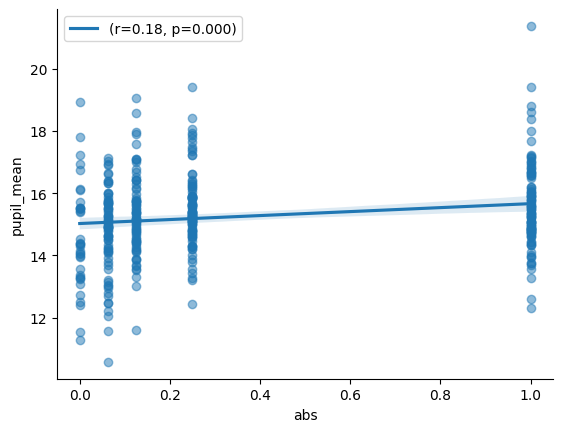

In [96]:
_, _ = check_session_significance(trials_df, pupil_df, (1,2), plot=True)

In [ ]:
# now for feedback modulation
from scipy import stats


def test_feedback_modulation(trials_df, pupil_df, plot=False):

    reward_responses = []
    error_responses = []
    
    valid_trials = trials_df.dropna(subset=['feedback_times', 'feedbackType'])
    
    for i, trial in valid_trials.iterrows():
        win_start = trial['feedback_times']
        win_end = trial['feedback_times'] + 1.5
        
        mask = (pupil_df['times'] >= win_start) & (pupil_df['times'] <= win_end)
        window_data = pupil_df.loc[mask, 'pupilDiameter_raw']
        
        if not window_data.empty:
            mean_response = np.nanmean(window_data)
            
            if trial['feedbackType'] == 1:
                reward_responses.append(mean_response)
            else:
                error_responses.append(mean_response)
                
    
    if len(reward_responses) > 5 and len(error_responses) > 5:
        t_stat, p_val = stats.ttest_ind(reward_responses, error_responses, nan_policy='omit')
        # if p_val < 0.05: # type: ignore
        #     print("Result: SIGNIFICANT feedback modulation.")
        # else:
        #     print("Result: NOT significant.")
            
        return p_val < 0.05 # type: ignore
    else:
        print("Insufficient data for statistical testing.")
        return False


In [93]:
def plot_uncorrected_feedback_psth(trials_df, pupil_df):

    pupil_df['session_zscore'] = zscore(pupil_df['pupilDiameter_raw'], nan_policy='omit')
    
    
    time_grid = np.arange(-0.25, 1.5, 0.016)
    aligned_trials = []
    
    valid_trials = trials_df.dropna(subset=['feedback_times', 'feedbackType'])
    
    for i, trial in valid_trials.iterrows():
        feedback_time = trial['feedback_times']
        fb_label = 'Reward' if trial['feedbackType'] == 1 else 'Error'
        
        win_start = feedback_time - 0.25
        win_end = feedback_time + 1.5
        
        
        mask = (pupil_df['times'] >= win_start) & (pupil_df['times'] <= win_end)
        t_raw = pupil_df.loc[mask, 'times'].values
        p_zscored = pupil_df.loc[mask, 'session_zscore'].values
        
        if len(t_raw) < 10 or np.isnan(p_zscored).all():
            continue
            
        t_shifted = t_raw - feedback_time 
        interpolator = interp1d(t_shifted, p_zscored, bounds_error=False, fill_value=np.nan)
        p_interp = interpolator(time_grid)
        
        trial_data = pd.DataFrame({
            'time': time_grid,
            'pupil_response': p_interp,
            'feedback': fb_label,
            'trial_id': i
        })
        aligned_trials.append(trial_data)
        
    all_data = pd.concat(aligned_trials, ignore_index=True)
    
    plt.figure(figsize=(9, 6))
    
    sns.lineplot(
        data=all_data, 
        x='time', 
        y='pupil_response', 
        hue='feedback', 
        palette={'Reward': '#2ca02c', 'Error': '#d62728'},
        linewidth=2
    )
    
    plt.axvline(0, color='black', linestyle='--', alpha=0.8, label='Feedback')
    
    plt.xlim(-0.30, 1.5)
    plt.xlabel('Time from Feedback (s)', fontsize=12)
    plt.ylabel('Pupil Size', fontsize=12)
    plt.title('Response to Feedback', fontsize=14)
    
    plt.legend()
    plt.tight_layout()
    sns.despine()
    
    return all_data

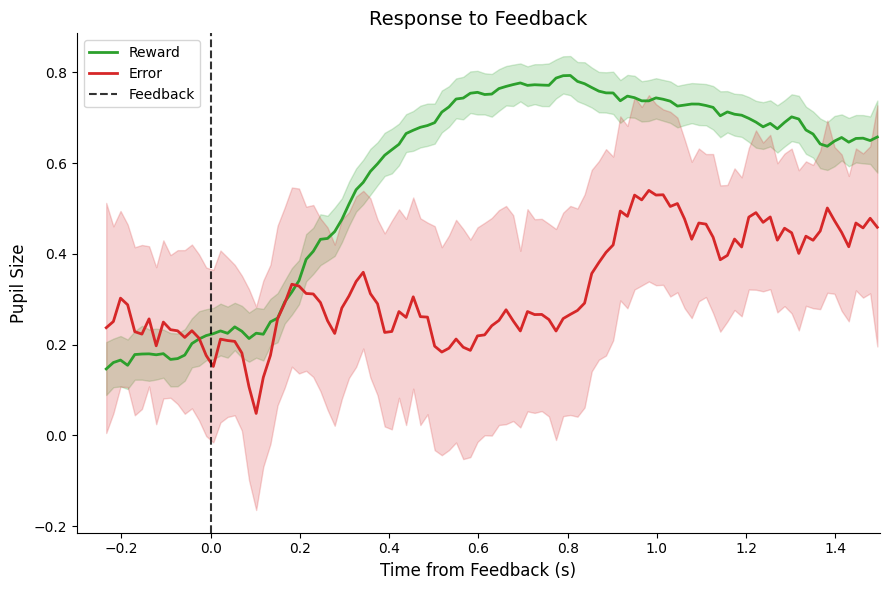

In [94]:
_ = plot_uncorrected_feedback_psth(trials_df, pupil_df)

In [101]:
test_feedback_modulation(trials_df, pupil_df)

Result: SIGNIFICANT feedback modulation.


np.True_